In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x0=2.8
v0=0
m=1
T=100
dx=1e-3
b = [0.5, 5]

In [3]:
def phi(x, l1=1, l2=1/np.sqrt(8)):
    return -np.exp(-x**2/l1**2)-8*np.exp(-(x-2)**2/l2**2)

In [4]:
def dphi_dx(x, dx=1e-3):
    return (phi(x + dx) - phi(x - dx)) / (2.0*dx)

In [5]:
def d2phi_dx2(x, dx=1e-3):
    return (phi(x + dx) - 2.0*phi(x) + phi(x - dx)) / (dx**2)

In [6]:
def a(x, v, mass=m, b=0):
    return -1/mass * dphi_dx(x) -b*v

In [7]:
def da_dx(x, mass=1.0):
    return - (1.0/mass)*d2phi_dx2(x)

In [8]:
def da_dv(b=0.0):
    return -b

In [9]:
def energy(x, v, mass=m):
    return 0.5*mass*v**2+phi(x)

In [10]:
def trapezoid(xn, vn, dt, mass=1.0, b=0, max_iter=50, tol_iter=1e-12):
    
    an = a(xn, vn, mass, b)  

    x_guess, v_guess = xn, vn

    for _ in range(max_iter):
        a_guess = a(x_guess, v_guess, mass, b)

        F1 = x_guess - xn - 0.5*dt*(v_guess + vn)
        F2 = v_guess - vn - 0.5*dt*(a_guess + an)

        dF1_dx = 1.0
        dF1_dv = -0.5*dt

        dF2_dx = -0.5*dt*da_dx(x_guess, mass)
        dF2_dv = 1.0-0.5*dt*da_dv(b)

        J = np.array([[dF1_dx, dF1_dv], [dF2_dx, dF2_dv]])
        R = np.array([F1, F2])

        dX = np.linalg.solve(J, -R)
        x_guess += dX[0]
        v_guess += dX[1]

        if max(abs(dX)) < tol_iter:
            break

    return x_guess, v_guess

In [11]:
def adaptive_integrate(d, x0, v0, T, dt0=1e-4, tol=1e-7, c=0.9, m=1.0, dx=1e-3, b=0):
    t = 0.0
    dt = dt0
    step_count = 0
    
    t_arr = np.array([t])
    dt_arr = np.array([dt])
    x_arr = np.array([x0])
    v_arr = np.array([v0])
    E_arr = np.array([energy(x0, v0, m)])
    
    x, v = x0, v0

    while t < T:
        if t + 2*dt > T:
            dt = (T-t)/2

        x_big, v_big = trapezoid(x, v, 2*dt, m, b)
        
        x_temp, v_temp = trapezoid(x, v, dt, m, b)
        x_small, v_small = trapezoid(x_temp, v_temp, dt, m, b)

        eps_x = np.abs(x_small - x_big) / (2**d - 1)
        eps_v = np.abs(v_small - v_big) / (2**d - 1)
        
        eps = max(eps_x, eps_v)

        if eps <= tol:
            t += 2 * dt
            x, v = x_small, v_small
            
            t_arr = np.append(t_arr, t)
            dt_arr = np.append(dt_arr, dt)
            x_arr = np.append(x_arr, x)
            v_arr = np.append(v_arr, v)
            E_arr = np.append(E_arr, energy(x, v))          
            
            step_count += 1 

        if eps == 0:
            dt *= 2 
        else:
            dt = c * dt * (tol / eps)**(1 / (d + 1))

    return t_arr, dt_arr, x_arr, v_arr, E_arr, step_count

In [12]:
results = {}

In [13]:
tt, dtt, xt, vt, Et, steps_t = adaptive_integrate(d=2, x0=x0, v0=v0, T=T, dt0=1e-6, tol=1e-7)
results['Trapez b=0'] = (tt, dtt, xt, vt, Et, steps_t)

In [14]:
tt1, dtt1, xt1, vt1, Et1, steps_t1 = adaptive_integrate(d=2, x0=x0, v0=v0, T=T, dt0=1e-6, tol=1e-7, b=b[0])
results['Trapez b=0.5'] = (tt1, dtt1, xt1, vt1, Et1, steps_t1)

In [15]:
tt2, dtt2, xt2, vt2, Et2, steps_t2 = adaptive_integrate(d=2, x0=x0, v0=v0, T=T, dt0=1e-6, tol=1e-7, b=b[1])
results['Trapez b=5'] = (tt2, dtt2, xt2, vt2, Et2, steps_t2)

In [16]:
for method, (t, dt, x, v, E, steps) in results.items():
    print(f"{method}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

Trapez b=0: wykonane kroki = 16154, T = 100.000
 dt: min=1.00e-06, max=1.75e-02, last=8.07e-03
----------------------------------------------------------------------------
Trapez b=0.5: wykonane kroki = 12161, T = 100.000
 dt: min=1.00e-06, max=1.49e+00, last=1.10e+00
----------------------------------------------------------------------------
Trapez b=5: wykonane kroki = 1353, T = 100.000
 dt: min=1.00e-06, max=2.12e+01, last=1.19e+00
----------------------------------------------------------------------------


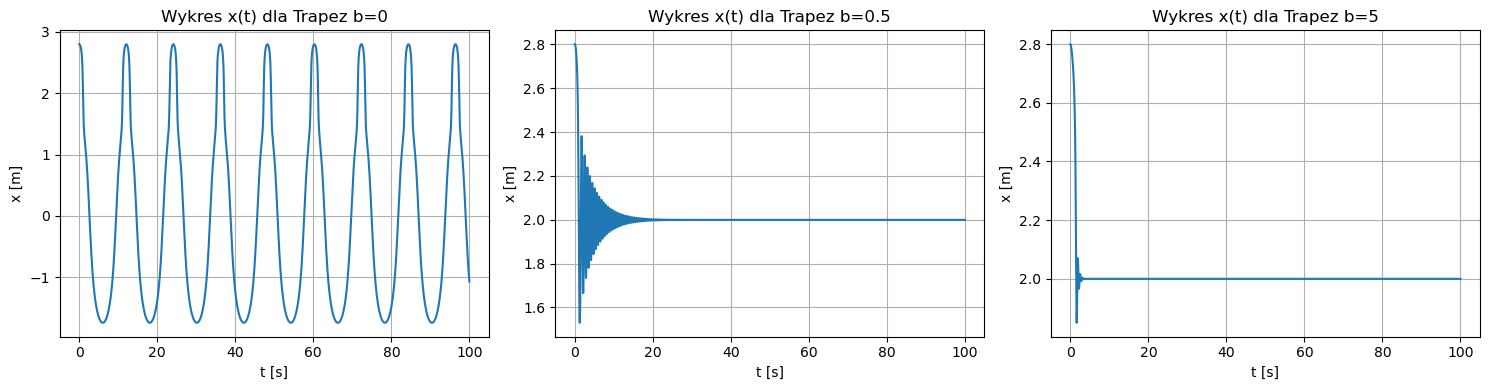

In [17]:
i = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, x)
    axes[i].set_title("Wykres x(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("x [m]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

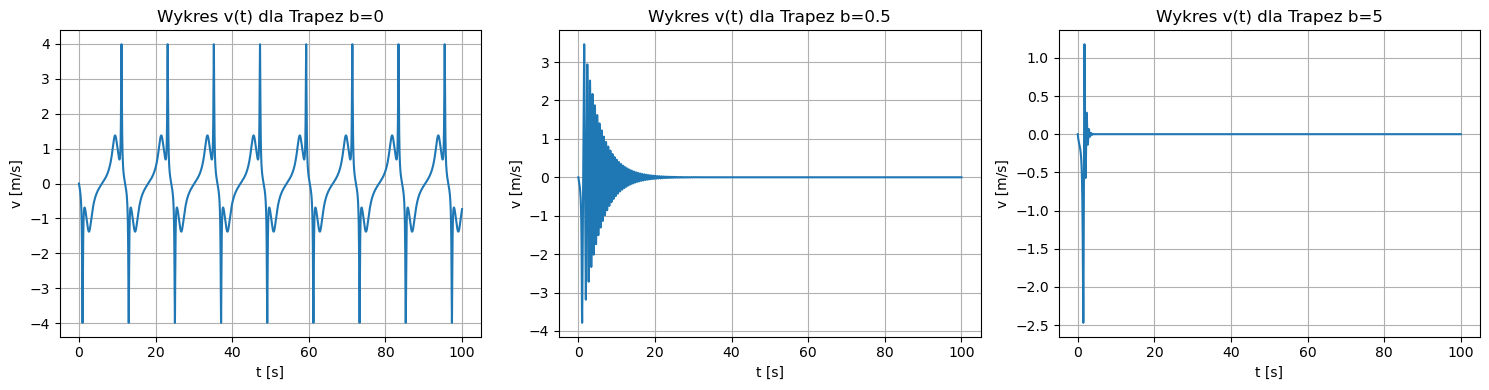

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, v)
    axes[i].set_title("Wykres v(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

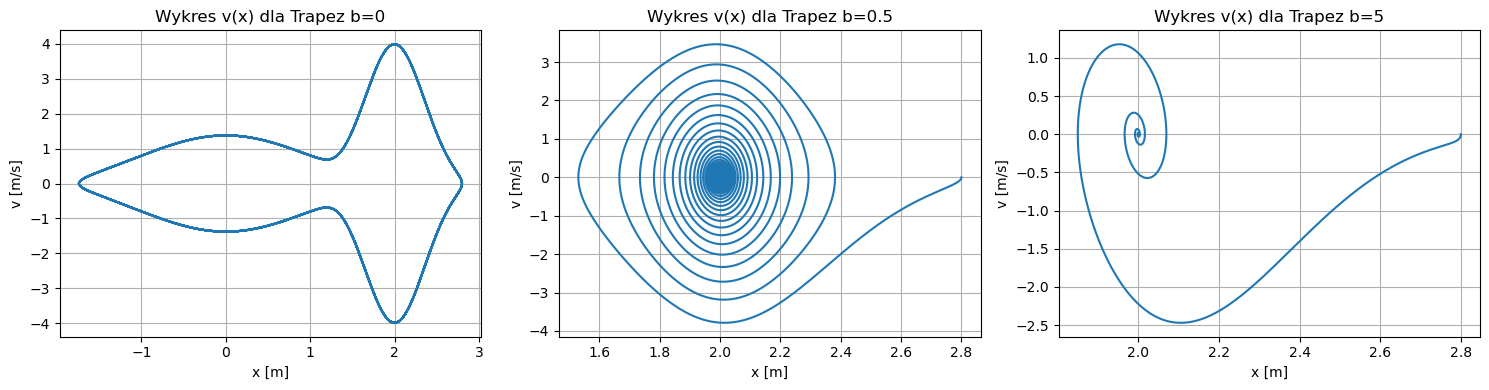

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(x, v)
    axes[i].set_title("Wykres v(x) dla {0:8s}".format(method))
    axes[i].set_xlabel("x [m]")    
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()

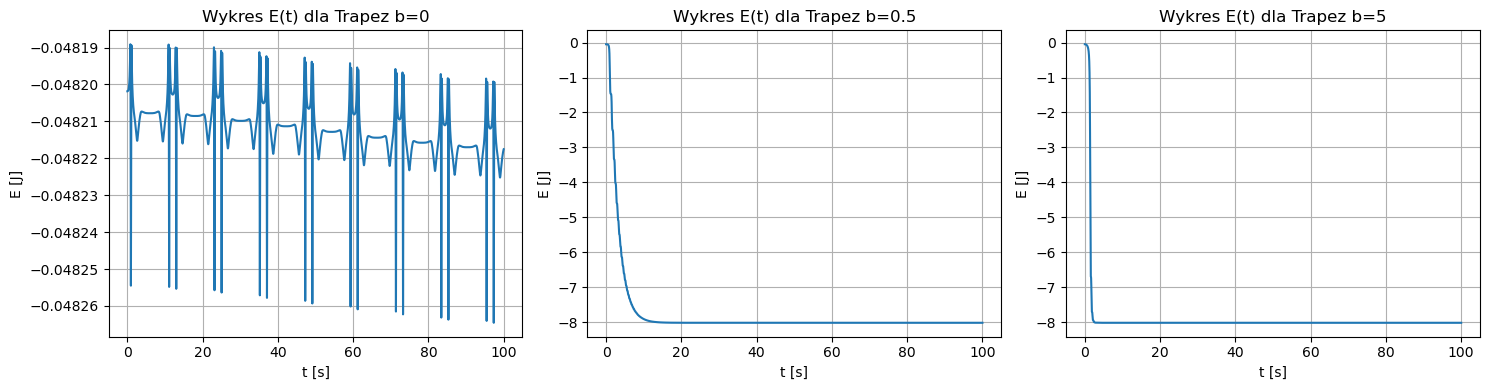

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for method, (t, dt, x, v, E, steps) in results.items():
    axes[i].plot(t, E)
    axes[i].set_title("Wykres E(t) dla {0:8s}".format(method))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("E [J]")    
    axes[i].grid(True)
    i+=1
i=0
plt.tight_layout()
plt.show()